In [182]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.transforms import RandomHorizontalFlip, ToTensor, Normalize, Compose
import random

In [179]:
def show_random_samples(dataset, num_samples=5):

    class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
        ]


    
    indices = random.sample(range(len(dataset)), num_samples) 

    plt.figure(figsize=(10, 5))
    
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        image = image.squeeze(0)                # Remove the channel dimension (C, H, W -> H, W)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"{class_names[label]}")

    plt.tight_layout()
    
    plt.show()

---

**TÄVLING! Klädeslassificering med Fully Connected Neural Networks**

Välkommen till dagens tävling! Vi ska arbeta med det kända FashionMNIST-datasetet, och försöka bygga en så bra classificationmodell som möjligt.

Läs mer om datasetet: https://github.com/zalandoresearch/fashion-mnist

---

**Ladda ner data**

Notera att vi här kan ladda ner FashionMNIST datasetet direkt, och att vi i den nedladdningen definiera olika transformationer på vår data. Detta är väldigt behjälpligt när vi jobbat med bilddata.
Vi kan exempelvis ändra om datatypen typp tensorer direkt, och även normalisera datan. 

Nedan anger vi två värden (en för varje axel, vi jobbar med 2d bilder här) till normalize, 0.5 i båda fallen - och vi kommer således att normalisera datan till att anta värden som följer en normalfördelning med medelvärde 0.5.  

Läs mer om tranformations i Pytorch [här](https://pytorch.org/vision/stable/transforms.html).

In [183]:
# Normalization transform
transform = transforms.Compose([RandomHorizontalFlip(p=0.5), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load training and test datasets with normalization
trainset = torchvision.datasets.FashionMNIST(root='./data/', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data/', train=False, download=True, transform=transform)


*Uppgift 1.1*

Undersök vad som nu finns i trainset. Does it make sense?

Till din hjälp kan du använda använda funktionen *show_random_samples* definierad ovan.

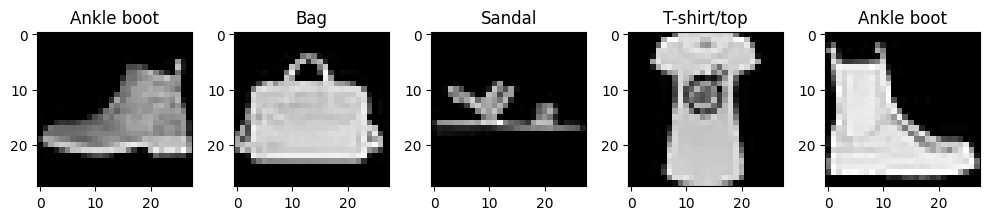

In [108]:
# TODO: work it out

show_random_samples(trainset, num_samples=5)

*Uppgift 1.2*

Undersök nu din träningsdata i mer detalj.

- Vad får du om du tar len(trainset)?
- Undersök nu en valfri training sample i trainset. Vad innehåller den? Vilken storlek/shape har varje?
    - Tips: ta, exempelvis, *trainset[0][0].size()*

- Vad tror du nu händer om vi kör torch.nn.Flatten() på en av bilderna? Undersök själv, och sök gärna online.

In [109]:
# TODO: work it out
print(len(trainset))
print(len(testset))
print(trainset[0][0].shape)  # Image shape
print(trainset[0][0].size()) 
print(trainset[0][1])        # Label  
print(torch.nn.Flatten(trainset[0][0]))  # Flattened image shape

60000
10000
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
9
Flatten(
  start_dim=tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
            -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
           [-1.0

Dataloaders skapar vi nedan. Notera att vi väljer batch_size här.

In [184]:
BATCH_SIZE = 128

# Dataloaders
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

---

**Nätverk**

In [185]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [223]:
class NeuralNetwork(nn.Module):

    def __init__(self, input_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)

        self.fc3 = nn.Linear(512, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, output_size)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.4)
        


        # TODO: Implement rest of layers and activations

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout2(x)
        x = self.fc4(x)
        # TODO: implement forward propagation, note that flatten must be the first action (why?)
        return x

---

**Train and eval loop**



- Sätt upp en träningsloop i PyTorch. Bestäm modell arkitektur själv samt regularisering, dropout etc.

- Iterera! Den som får bästa och stabilaste resultatet vinner priset!!

Glöm inte att även spara train- och testloss (likt hur vi gjort tidigare) så att ni kan plotta kurvorna!

In [227]:
EPOCHS = 50         # välj lämpligt startvärde
LEARNING_RATE = 0.001  # välj lämpligt startvärde 
INPUT_SIZE = 784     # vad måste denna vara? 28 * 28 = 784
OUTPUT_SIZE = 10    # vad måste denna vara? klasser i FashionMNIST = 10


model = NeuralNetwork(INPUT_SIZE, OUTPUT_SIZE).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # our new loss, for multiclass classification
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)  # Adam optimizer with weight decay
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.012, steps_per_epoch=len(trainloader), epochs=EPOCHS, pct_start=0.3, anneal_strategy='cos')

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        
        images, labels = images.to(device), labels.to(device)   # lägger över träningsdata till device (gpu om tillgänglig) innan leverans till modellen

        optimizer.zero_grad()          # nollställer gradienterna innan bakåtpropagering
        outputs = model(images)        # framåtpropagering
        loss = criterion(outputs, labels)  # beräknar förlust
        loss.backward()                # bakåtpropagering
        optimizer.step()               # uppdaterar vikterna 
        scheduler.step()
   

        running_loss += loss.item()    # ackumulerar förlusten

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(testloader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Test Accuracy: {100 * correct / total:.2f}%")
print("Training complete.")

Epoch [1/20], Train Loss: 1.1558, Test Loss: 1.0590, Test Accuracy: 76.79%
Epoch [2/20], Train Loss: 1.1323, Test Loss: 1.0600, Test Accuracy: 76.74%
Epoch [3/20], Train Loss: 1.1311, Test Loss: 1.0570, Test Accuracy: 76.88%
Epoch [4/20], Train Loss: 1.1320, Test Loss: 1.0547, Test Accuracy: 76.67%
Epoch [5/20], Train Loss: 1.1335, Test Loss: 1.0573, Test Accuracy: 76.79%
Epoch [6/20], Train Loss: 1.1314, Test Loss: 1.0585, Test Accuracy: 76.75%
Epoch [7/20], Train Loss: 1.1323, Test Loss: 1.0592, Test Accuracy: 76.99%
Epoch [8/20], Train Loss: 1.1321, Test Loss: 1.0573, Test Accuracy: 76.76%
Epoch [9/20], Train Loss: 1.1316, Test Loss: 1.0576, Test Accuracy: 76.98%
Epoch [10/20], Train Loss: 1.1323, Test Loss: 1.0558, Test Accuracy: 76.70%
Epoch [11/20], Train Loss: 1.1315, Test Loss: 1.0569, Test Accuracy: 76.78%
Epoch [12/20], Train Loss: 1.1336, Test Loss: 1.0571, Test Accuracy: 76.84%


KeyboardInterrupt: 

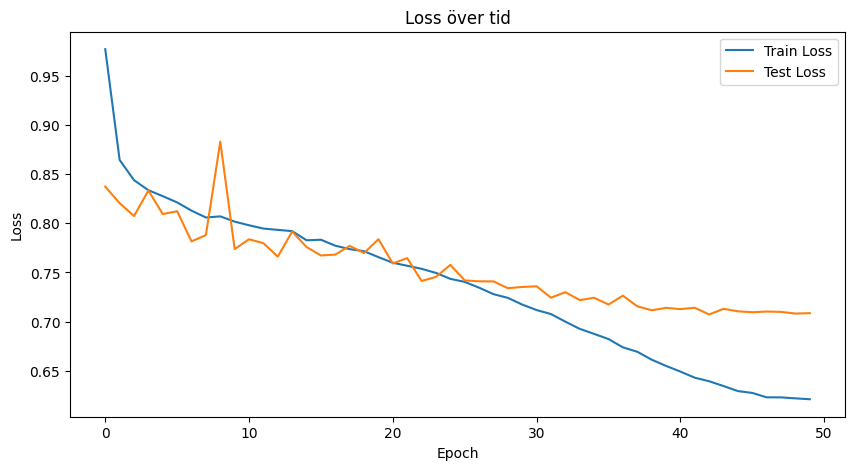

In [225]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss över tid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()